# Injury severity: gamma GLM on severity tiers

Predicts days missed per injury (soccer data). Code lives in `severity.py`; needs MySQL with soccer data loaded. Career-ending injuries: see `career_ending_model.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import severity as sev

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 200)

## 1. Modeling table

One row per injury; response `days_missed`. Excludes injuries > 1,000 days, non-injuries (rest, suspensions) and ages outside 15–45. Open injuries are flagged `censored` and left out of fitting and scoring.

Predictors: severity tier, `position_group`, `age` (+age²), `log(1 + prior_injuries)`, `reinjury_60d`, `prior_same_part`.

In [2]:
data = sev.build_dataset("Soccer", max_days=1000)
train, test = sev.split(data)          # split by player
print(f"{len(data):,} injuries, {data.pid.nunique():,} players, {data.censored.sum():,} still open, "
      f"{data.injury_class.nunique()} rating classes")
print(f"train {len(train):,}  /  test {len(test):,}")
data[["days_missed", "age", "prior_injuries", "reinjury_60d", "prior_same_part"]].describe().round(2).T

163,414 injuries, 34,429 players, 1,474 still open, 57 rating classes
train 130,324  /  test 33,090


,count,mean,std,min,25%,50%,75%,max
days_missed,163414.0,48.99,74.53,1.00,10.00,22.00,52.00,1000.00
age,163414.0,26.41,4.64,15.03,22.79,26.15,29.74,44.98
prior_injuries,163414.0,5.01,6.37,0.00,1.00,3.00,7.00,71.00
reinjury_60d,163414.0,0.24,0.42,0.00,0.00,0.00,0.00,1.00
prior_same_part,163414.0,0.25,0.43,0.00,0.00,0.00,0.00,1.00


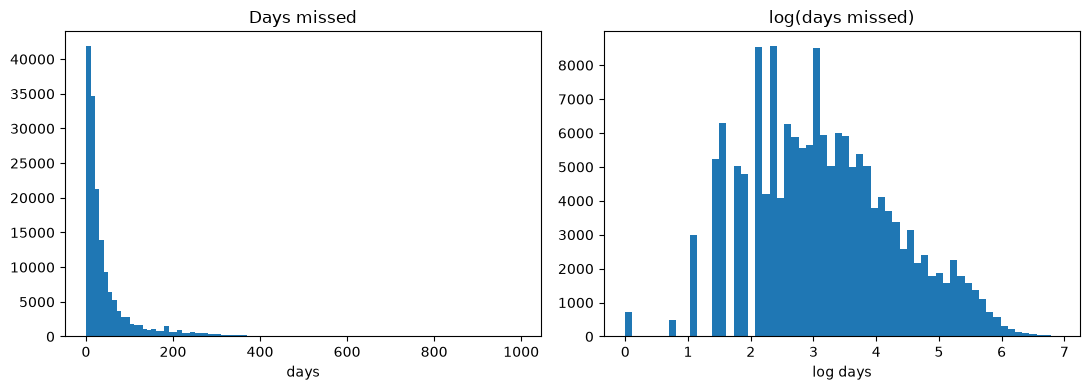

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
done = sev.completed(data)
ax[0].hist(done.days_missed, bins=100); ax[0].set(title="Days missed", xlabel="days")
ax[1].hist(np.log(done.days_missed), bins=60); ax[1].set(title="log(days missed)", xlabel="log days")
plt.tight_layout()

Heavily right-skewed → gamma GLM with log link, not linear regression.

## 2. Rating classes

Body region × injury type; cells with ≥ 300 injuries stand alone, rarer ones pool by type, then by region, then "Other (rare)". Built from counts only (no leakage).

In [4]:
sev.class_table(data)

,injuries,mean_days,median_days
injury_class,,,
Achilles - Tear / rupture,577,203.3,190.0
Knee - Tear / rupture,6541,190.4,191.0
Knee - Surgery,1742,166.5,150.0
Lower leg - Fracture,747,151.5,130.0
Fracture - other sites,362,123.0,101.5
Surgery - other sites,488,116.2,96.0
Ankle - Surgery,360,114.8,95.0
Knee - Ligament / joint,3323,110.9,63.0
Unknown - Fracture,1099,85.6,59.0


## 3. ▶ GLM fit — gamma GLM (log link)

Fits a no-predictor gamma baseline and the gamma GLM on severity tiers. Tiers merge adjacent rating classes until neighbours differ at p < 0.05 (training data only).

In [5]:
# ===================== GLM FIT =====================
models = sev.fit_all(train)
tiered = models["Gamma GLM, severity tiers"]

  fitting Gamma, no predictors ...


  fitting Gamma GLM, severity tiers ...


## 4. Held-out comparison

`log_lik` (higher better), `gamma_dev` (lower better), `mae`/`rmse` (days), `mean_pred` vs. `(actual)`, `above_p90` (should be ~10%).

In [6]:
sev.compare(models, test)

,log_lik,gamma_dev,mae,rmse,mean_pred,above_p90
model,,,,,,
"Gamma, no predictors",-4.8515,1.3912,44.02,70.97,48.24,0.1055
"Gamma GLM, severity tiers",-4.6184,0.9286,33.27,59.32,48.27,0.0894
(actual),NaN,NaN,NaN,NaN,47.51,NaN


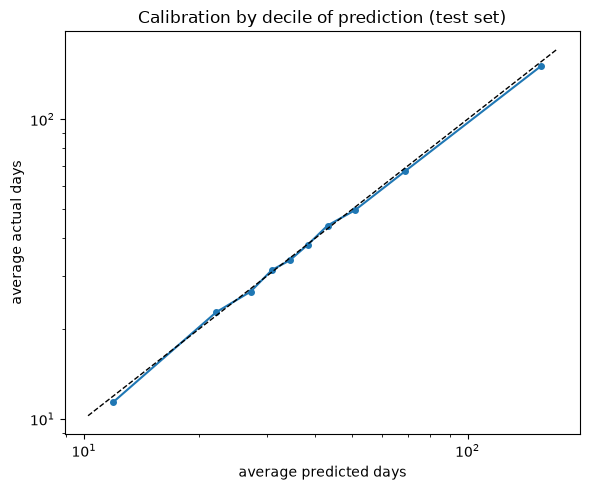

In [7]:
cal = sev.calibration(models, test)      # baseline is constant, so skipped
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(cal.pred, cal.actual, "o-", ms=4)
lim = [cal[["pred", "actual"]].min().min() * 0.9, cal[["pred", "actual"]].max().max() * 1.1]
ax.plot(lim, lim, "k--", lw=1)
ax.set(xscale="log", yscale="log", xlabel="average predicted days", ylabel="average actual days",
       title="Calibration by decile of prediction (test set)")
plt.tight_layout()

PIT histogram: flat = good fit; spike at 1 = tail too thin.

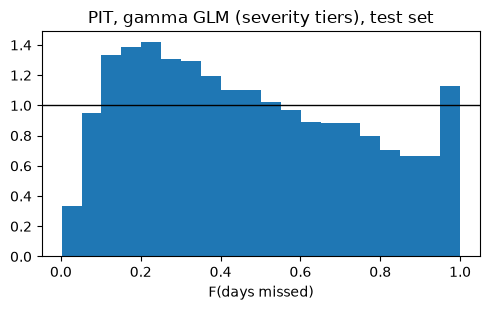

In [8]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.hist(tiered.cdf(tiered._tiers(sev.completed(test))), bins=20, density=True)
ax.axhline(1, color="k", lw=1)
ax.set(title="PIT, gamma GLM (severity tiers), test set", xlabel="F(days missed)")
plt.tight_layout()

## 5. Relativities

`exp(coef)` multiplies expected days. Reference: hamstring tier, 26-year-old midfielder, no injury history.

In [9]:
rel = sev.relativities(tiered)
rel

,multiplier,ci_low,ci_high,p_value
Intercept,51.3369,49.8196,52.9003,0.0000
severity_tier = Tier 1,0.2658,0.2568,0.2752,0.0000
severity_tier = Tier 2,0.4753,0.4567,0.4946,0.0000
severity_tier = Tier 3,0.5468,0.4979,0.6004,0.0000
severity_tier = Tier 4,0.6266,0.6075,0.6463,0.0000
severity_tier = Tier 5,0.7528,0.7223,0.7846,0.0000
severity_tier = Tier 6,0.8375,0.8143,0.8614,0.0000
severity_tier = Tier 7,0.9091,0.8633,0.9574,0.0003
severity_tier = Tier 9,1.0698,1.0162,1.1262,0.0101
severity_tier = Tier 10,1.2852,1.2325,1.3403,0.0000


## 6. Severity tiers

Per tier: size, observed days (training set), multiplier vs. the hamstring tier and member rating classes.

In [10]:
tiers = tiered.tier_table(train)
print(f"{len(tiers)} tiers from {data.injury_class.nunique()} rating classes")
tiers

16 tiers from 57 rating classes


,injuries,mean_days,median_days,multiplier,ci_low,ci_high,classes
severity_tier,,,,,,,
Tier 1,11051,11.2,8.0,0.266,0.257,0.275,Illness (unspecified)
Tier 2,6945,20.1,11.0,0.475,0.457,0.495,Head - Concussion; Knee - Knock / bruise; Trun...
Tier 3,821,23.7,11.0,0.547,0.498,0.600,Foot - Knock / bruise; Knock / bruise - other ...
Tier 4,17949,26.6,17.0,0.627,0.608,0.646,Ankle - Ligament / joint; Head (unspecified); ...
Tier 5,5999,31.0,22.0,0.753,0.722,0.785,Calf (unspecified); Calf - Strain / muscle; Ha...
Tier 6,36599,36.2,21.0,0.838,0.814,0.861,Groin (unspecified); Muscle (unspecified) - Te...
Tier 7,3256,39.8,21.0,0.909,0.863,0.957,Arm / hand (unspecified); Back / neck (unspeci...
Tier 8,11448,42.8,28.0,1.000,1.000,1.000,Ankle (unspecified); Calf - Tear / rupture; Ha...
Tier 9,3276,46.5,29.0,1.070,1.016,1.126,Arm / hand - Fracture; Foot (unspecified); Gro...


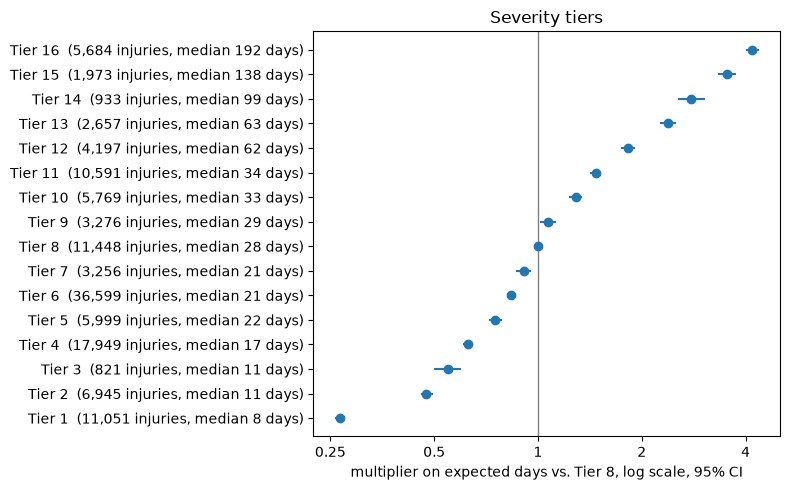

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
y = range(len(tiers))
ax.errorbar(tiers.multiplier, y, xerr=[tiers.multiplier - tiers.ci_low, tiers.ci_high - tiers.multiplier], fmt="o", ms=6)
ax.set_yticks(list(y), [f"{t}  ({n:,} injuries, median {m:.0f} days)" for t, n, m in zip(tiers.index, tiers.injuries, tiers.median_days)])
ax.axvline(1, color="grey", lw=1)
ticks = [0.25, 0.5, 1, 2, 4]
ax.set(xscale="log", xlabel=f"multiplier on expected days vs. {tiered.ref_tier}, log scale, 95% CI", title="Severity tiers")
ax.set_xticks(ticks, [f"{t:g}" for t in ticks]); ax.minorticks_off()
plt.tight_layout()

## Results

- **Severity tiers:** 57 rating classes merge into 16 tiers, from ×0.27 (illness, median 8 days) to ×4.19 (Achilles/knee tears, median 192 days) vs. the hamstring tier.
- **Test set vs. baseline:** gamma deviance 1.391 → 0.929, MAE 44.0 → 33.3 days, RMSE 71.0 → 59.3, log-lik −4.85 → −4.62. Mean prediction 48.3 vs. 47.5 actual.
- **Tail:** 8.9% of test injuries exceed the predicted p90 (target 10%), so the gamma tail is slightly too thin.
- **Player effects:** same-part recurrence +9%, reinjury within 60 days +3%, goalkeepers +4%, attackers −2%; more prior injuries go with shorter absences (×0.84 per unit of log(1 + prior)), likely a record-keeping effect. Age is U-shaped with a small effect.